In [1]:
from typing import List

In [2]:
import tensorflow as tf

# List available hardware
devices: List = tf.config.list_physical_devices()
print(f"Devices found: {devices}")

2026-03-31 23:00:35.554192: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-31 23:00:35.564107: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-31 23:00:35.578368: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-31 23:00:35.578403: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-31 23:00:35.588398: I tensorflow/core/platform/cpu_feature_gua

Devices found: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-03-31 23:00:38.003784: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-31 23:00:38.047976: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-31 23:00:38.048017: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [3]:
gpu_devices: List = tf.config.list_physical_devices("GPU")

if gpu_devices:
    print(f"GPU devices found: {gpu_devices}")

    for each_gpu_device in gpu_devices:
        tf.config.experimental.set_memory_growth(each_gpu_device, True)

else:
    print("Running on Local CPU")

GPU devices found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Remarks: How to Fetch the Dataset

We will use `Kesejahteraan Pekerja Indonesia` dataset from [Kaggle](https://www.kaggle.com/datasets/rezkyyayang/pekerja-sejahtera) for this project

### Dataset Description

Messr Rezky Yayang Hamid curated this data from BPS in 2023. The dataset contains several metrics that gauge workers' well-being around Indonesia. The metrics included in this dataset consists of:
* upah.df.csv - this dataset gives information on the average hourly wage of workers grouped by provinces and years
* ump.df.csv - this dataset gives information about `upah minimum provinsi (UMP)`, which is the minimum wage grouped by provinces and years
* gk.df.csv = this dataset gives information about 'Garis Kemiskinan per kapita', which is poverty line on per capita basis grouped by province, year, survey period, type of outlay, and region of domicile
* peng.df.csv - this dataset gives information about the average spending on per capita basis grouped by province, year, type of outlay, and region of domicile


### Authentication

Authentication is needed to download this dataset from Kaggle

First, you will need a Kaggle account. You can sign up [here](https://www.kaggle.com/account/login)

After login, you can download your Kaggle API token at [here](https://www.kaggle.com/settings) by clicking on the "Generate new Token" button under the "API" section.

You have several options to authenticate:

Option 1: kagglehub.login()

```Python
import kagglehub

kagglehub.login()
```
This will prompt you to enter your Kaggle API token.

Option 2: Environment Variable

```Bash
export KAGGLE_API_TOKEN=xxxxxxxxxxxxxx # Coped from the settings UI
```

Option 3: API Token File

Store your Kaggle API token obtained from your [setting page](https://www.kaggle.com/settings) to a file located in `~/.kaggle/access_token`

Option 4: Google Colab Secret

If you are running this notebook from Google Cloud, then you can store your API token in a Colab secret named `KAGGLE_API_TOKEN`.

Instructions on adding secrets in Colab can be found [here](https://www.googlecloudcommunity.com/gc/Cloud-Hub/How-do-I-add-secrets-in-Google-Colab-Enterprise/m-p/784866)

Option 5: Legacy API credentials file

From your [Kaggle Account Setting Page](https://www.kaggle.com/settings), under the "Legacy API Credentials", click on the "Create Legeacy API Key" button to generate a `kaggle.json` file and store it at `~/.kaggle/kaggle.json`

In [4]:
# Authenticate Kaggle

import os
from pathlib import Path


import kagglehub

is_authenticated: bool = False

api_key_path: Path = Path("~/.kaggle/kaggle.json").expanduser()
is_api_key_exists: bool = True if api_key_path.exists() else False

api_token_path: Path = Path("~/.kaggle/access_token").expanduser()
is_api_token_exists: bool = True if api_token_path.exists() else False

## Check if running in Colab
def is_colab() -> bool:
    """
    Small utility function to check if this notebook is running on Colab
    :return: Boolean indication if this script is running on Colab
    :rtype bool
    """
    try:
        import google.colab
        return True
    except ImportError:
        return False

is_colab_secret_exists: bool = False
if is_colab():
    from google.colab import userdata

    try:
        is_colab_secret_exists = True if userdata.get("KAGGLE_API_TOKEN") else False
    except userdata.SecretNotFoundError:
        is_colab_secret_exists = False

is_token_env_exists: bool = True if os.getenv("KAGGLE_API_TOKEN") else False

is_token_via_login: bool = False
if all([
    not is_api_key_exists
    , not is_api_token_exists
    , not is_colab_secret_exists
    , not is_token_env_exists
]):
    # if everything above fails, then login interactively
    # this will ask you to input the Kaggle API Token from a UI
    kagglehub.login()
    is_token_via_login = True


if any([
    is_api_key_exists
    , is_api_token_exists
    , is_token_env_exists
    , is_colab_secret_exists
    , is_token_via_login
]):
    is_authenticated = True
    print("Kagglehub has been authenticated")

else:
    raise Exception(" 🛑 Kagglehub fails to authenticate")

Kagglehub has been authenticated


## Remarks: Download the Dataset

In this section, we will download the dataset from Kaggle.

We want to detect if any `.csv` files already present under `dataset/` folder.

If not, then we: (1) would download the dataset from Kaggle, (2) copy the downloaded data from Kaggle's `cache/` folder into the project's `dataset/` folder. If `.csv` files already present in the `dataset/` folder, then we will simply load the data from the `dataset/` folder.

This way, we can avoid downloading the dataset every time we run this notebook.

In [5]:
# Download Data Smartly
# If the data is not yet downloaded, we will first download the data from Kaggle to `dataset` folder, and then load them to pandas
# Else, we will load the data from the `dataset` folder directly to pandas

from pathlib import Path
import shutil

import kagglehub

kaggle_dataset_handler_str: str = "rezkyyayang/pekerja-sejahtera"

project_root: Path = Path.cwd().expanduser()
dataset_folder: Path = project_root / "dataset"

dataset_folder.mkdir(parents=True, exist_ok=True)

available_files = sorted(each_found_file.name for each_found_file in dataset_folder.glob("*.csv"))

if available_files:
    print("Dataset already exists locally. Using files from `dataset` folder.")
    print("Available files:")
    print(available_files)
else:
    downloaded_path_str: str = kagglehub.dataset_download(
        handle=kaggle_dataset_handler_str
    )
    downloaded_path: Path = Path(downloaded_path_str)
    downloaded_files = sorted(each_csv_file_path.name for each_csv_file_path in downloaded_path.glob("*.csv"))

    print("Downloaded files:")
    print(downloaded_files)

    for each_downloaded_file in downloaded_files:
        shutil.copy2(
            downloaded_path / each_downloaded_file,
            dataset_folder / each_downloaded_file,
        )

    available_files = sorted(each_found_file.name for each_found_file in dataset_folder.glob("*.csv"))

Dataset already exists locally. Using files from `dataset` folder.
Available files:
['gk.csv', 'gk.df.csv', 'peng.csv', 'peng.df.csv', 'ump.csv', 'ump.df.csv', 'upah.csv', 'upah.df.csv']


## Remarks: Load the Dataset into Pandas DataFrame

In this section, we would simply load the dataset into Pandas DataFrame by calling `pd.read_csv()` method

We will also glimpse the number of rows, and if there are any null values we need to handle later.

For this inspection, we will use the `info()` method of Pandas DataFrame.


In [6]:
import pandas as pd

# Load upah_df
upah_path: Path = dataset_folder / "upah.df.csv"
upah_df: pd.DataFrame = pd.read_csv(upah_path)

print("upah_df.info():")
upah_df.info()
print("##"*10)

# Load ump_df
ump_path: Path = dataset_folder / "ump.df.csv"
ump_df: pd.DataFrame = pd.read_csv(ump_path)

print("ump_df.info():")
ump_df.info()
print("##"*10)

# Load peng_df
peng_path: Path = dataset_folder / "peng.df.csv"
peng_df: pd.DataFrame = pd.read_csv(peng_path)

print("peng_df.info():")
peng_df.info()
print("##"*10)

# Load gk_df
gk_path: Path = dataset_folder / "gk.df.csv"
gk_df: pd.DataFrame = pd.read_csv(gk_path)

print("gk_df.info():")
gk_df.info()
print("##"*10)



upah_df.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280 entries, 0 to 279
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   provinsi  280 non-null    object
 1   tahun     280 non-null    int64 
 2   upah      280 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 6.7+ KB
####################
ump_df.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 735 entries, 0 to 734
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   provinsi  735 non-null    object 
 1   tahun     735 non-null    int64  
 2   ump       711 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 17.4+ KB
####################
peng_df.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4620 entries, 0 to 4619
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   provinsi  4620 n

## Remarks: Consolidate The Pandas DataFrame into One

In this section, we want to consolidate the scattered pandas dataframes loaded earlier into one unified dataframe for further analysis and processing. This consolidation would help us to understand the data distribution better whence we do Ecxploratory Data Analysis (EDA).

Notice that we need to convert the `upah` column from average hourly wage to average monthly wage to match the time period of the rest other columns.


In [10]:
consol_df = gk_df.merge(
    right=peng_df,
    how="left",
    on=["provinsi", "tahun", "jenis", "daerah"]   # removed "periode"
)

consol_df.rename(
    columns = {
        "periode" : "gk_periode_survei"
        , "jenis" : "jenis_pengeluaran"

    }
    , inplace = True
)

consol_df = consol_df.merge(
    right = ump_df
    , how = "left"
    , on = ["provinsi", "tahun"]
)

consol_df = consol_df.merge(
    right = upah_df
    , how = "left"
    , on = ["provinsi", "tahun"]
)

COUNT_WORKING_HOURS_PER_MONTH: int = 173 # unit: working_hourse / month

consol_df["upah"] = consol_df["upah"] * COUNT_WORKING_HOURS_PER_MONTH

print("consol_df.info():")
consol_df.info()
print("##"*10)
consol_df.head(n=10)



consol_df.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5460 entries, 0 to 5459
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   provinsi           5460 non-null   object 
 1   jenis_pengeluaran  5460 non-null   object 
 2   daerah             5460 non-null   object 
 3   tahun              5460 non-null   int64  
 4   gk_periode_survei  5460 non-null   object 
 5   gk                 5261 non-null   float64
 6   peng               5396 non-null   float64
 7   ump                5448 non-null   float64
 8   upah               5040 non-null   float64
dtypes: float64(4), int64(1), object(4)
memory usage: 384.0+ KB
####################


,provinsi,jenis_pengeluaran,daerah,tahun,gk_periode_survei,gk,peng,ump,upah
0,ACEH,MAKANAN,PERKOTAAN,2015,MARET,293697.0,466355.0,1900000.0,1942098.0
1,ACEH,MAKANAN,PERKOTAAN,2015,SEPTEMBER,302128.0,466355.0,1900000.0,1942098.0
2,ACEH,MAKANAN,PERKOTAAN,2016,MARET,306243.0,548853.0,2118500.0,2357471.0
3,ACEH,MAKANAN,PERKOTAAN,2016,SEPTEMBER,319768.0,548853.0,2118500.0,2357471.0
4,ACEH,MAKANAN,PERDESAAN,2015,MARET,297479.0,395136.0,1900000.0,1942098.0
5,ACEH,MAKANAN,PERDESAAN,2015,SEPTEMBER,306737.0,395136.0,1900000.0,1942098.0
6,ACEH,MAKANAN,PERDESAAN,2016,MARET,315697.0,412251.0,2118500.0,2357471.0
7,ACEH,MAKANAN,PERDESAAN,2016,SEPTEMBER,324854.0,412251.0,2118500.0,2357471.0
8,ACEH,MAKANAN,PERDESAANPERKOTAAN,2015,MARET,296406.0,415354.0,1900000.0,1942098.0
9,ACEH,MAKANAN,PERDESAANPERKOTAAN,2015,SEPTEMBER,305428.0,415354.0,1900000.0,1942098.0


## Remarks: Data Pre-Processing - Convert String Columns into Categorical

In this section, we will convert string columns into appropriate categorical type

Furthermore, we also change the year (`tahun`) into categorical type. We do this to simplify the modeling as we would concentrate on building MLP model in this project.

We can revisit this case again next time once we learn about sequential deep learning, e.g., LSTM, RNN - which have better way to handle panel time data like this.

In [11]:
# convert string columns into categorical

# convert all string columns into categorical data type
string_cols: List[str] = consol_df.select_dtypes(include=["object", "string"]).columns.to_list()
for each_col in string_cols:
    consol_df[each_col] = consol_df[each_col].astype("category")

# convert the `tahun` column also into categorical data type
consol_df["tahun"] = consol_df["tahun"].astype("category")

consol_df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5460 entries, 0 to 5459
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   provinsi           5460 non-null   category
 1   jenis_pengeluaran  5460 non-null   category
 2   daerah             5460 non-null   category
 3   tahun              5460 non-null   category
 4   gk_periode_survei  5460 non-null   category
 5   gk                 5261 non-null   float64 
 6   peng               5396 non-null   float64 
 7   ump                5448 non-null   float64 
 8   upah               5040 non-null   float64 
dtypes: category(5), float64(4)
memory usage: 199.5 KB


## Remarks: Data Pre-Processing - Impute `Null` values with Median

Notice from the previous cell that the columns `gk`, `peng`, `ump`, and `upah` still have `null` values

Hence, in this section, we will impute these missing values with the median of the column.

Why median? Because economic metrics usually are skewed. Hence, by imputing using median, we would avoid its value from being affected by the outliers.

Furthermore, we define a `hierarchical_imputation()` function to perform this imputation hierarchically

The list of list in the `group_level` parameters should starts from more specific to more generic

For example

```Python
consol_df["gk"] = hierarchical_imputation(
    df = consol_df
    , column = "gk"
    , group_levels = [
        ["provinsi", "jenis_pengeluaran", "daerah", "tahun", "gk_periode_survei"]
        , ["provinsi", "jenis_pengeluaran", "daerah", "tahun"]
        , ["provinsi", "daerah", "tahun"]
        , ["provinsi", "tahun"]
    ]
)
```

you can do the same for other numeric columns


In [12]:
def hierarchical_imputation(
        df: pd.DataFrame
        , column: str
        , group_levels: List[List[str]]
) -> pd.Series:
    """
    Impute missing values hierarchically using grouped medians.

    Fill missing values in a numeric column by applying median imputation
    across a sequence of grouping levels, from the most specific grouping
    to broader fallback groupings. Any remaining missing values after all
    grouping levels are filled with the overall median of the column.

    Parameters
    ----------
    df : pandas.DataFrame
        Input DataFrame containing the column to be imputed and the grouping
        columns used for hierarchical aggregation.
    column : str
        Name of the numeric column whose missing values will be imputed.
    group_levels : list of list of str
        Ordered list of grouping column combinations used for hierarchical
        imputation. Each inner list defines one grouping level. Earlier
        entries should be more specific, while later entries should be
        broader fallback groupings.

    Returns
    -------
    pandas.Series
        A Series containing the imputed values for the specified column,
        where missing values are filled using grouped medians first and the
        overall column median as the final fallback.
    """

    result: pd.DataFrame = df[column].copy()

    for each_group in group_levels:
        result = result.fillna(
            df.groupby(each_group, observed = True)[column].transform("median")
        )

    return result.fillna(df[column].median())

In [13]:
# impute `null` values in numerical columns with median from respective groups

consol_df["gk"] = hierarchical_imputation(
    df = consol_df
    , column = "gk"
    , group_levels = [
        ["provinsi", "jenis_pengeluaran", "daerah", "tahun", "gk_periode_survei"]
        , ["provinsi", "jenis_pengeluaran", "daerah", "tahun"]
        , ["provinsi", "daerah", "tahun"]
        , ["provinsi", "tahun"]
    ]
)

consol_df["peng"] = hierarchical_imputation(
    df = consol_df
    , column = "peng"
    , group_levels = [
        ["provinsi", "jenis_pengeluaran", "daerah", "tahun"]
        , ["provinsi", "daerah", "tahun"]
        , ["provinsi", "tahun"]
    ]
)

consol_df["ump"] = hierarchical_imputation(
    df = consol_df
    , column = "ump"
    , group_levels = [
        ["provinsi", "tahun"]
        , ["provinsi"]
    ]
)

consol_df["upah"] = hierarchical_imputation(
    df = consol_df
    , column = "upah"
    , group_levels = [
        ["provinsi", "tahun"]
        , ["provinsi"]
    ]
)

print("consol_df.info():")
consol_df.info()
print("##"*10)
consol_df.head(n=10)



consol_df.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5460 entries, 0 to 5459
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   provinsi           5460 non-null   category
 1   jenis_pengeluaran  5460 non-null   category
 2   daerah             5460 non-null   category
 3   tahun              5460 non-null   category
 4   gk_periode_survei  5460 non-null   category
 5   gk                 5460 non-null   float64 
 6   peng               5460 non-null   float64 
 7   ump                5460 non-null   float64 
 8   upah               5460 non-null   float64 
dtypes: category(5), float64(4)
memory usage: 199.5 KB
####################


,provinsi,jenis_pengeluaran,daerah,tahun,gk_periode_survei,gk,peng,ump,upah
0,ACEH,MAKANAN,PERKOTAAN,2015,MARET,293697.0,466355.0,1900000.0,1942098.0
1,ACEH,MAKANAN,PERKOTAAN,2015,SEPTEMBER,302128.0,466355.0,1900000.0,1942098.0
2,ACEH,MAKANAN,PERKOTAAN,2016,MARET,306243.0,548853.0,2118500.0,2357471.0
3,ACEH,MAKANAN,PERKOTAAN,2016,SEPTEMBER,319768.0,548853.0,2118500.0,2357471.0
4,ACEH,MAKANAN,PERDESAAN,2015,MARET,297479.0,395136.0,1900000.0,1942098.0
5,ACEH,MAKANAN,PERDESAAN,2015,SEPTEMBER,306737.0,395136.0,1900000.0,1942098.0
6,ACEH,MAKANAN,PERDESAAN,2016,MARET,315697.0,412251.0,2118500.0,2357471.0
7,ACEH,MAKANAN,PERDESAAN,2016,SEPTEMBER,324854.0,412251.0,2118500.0,2357471.0
8,ACEH,MAKANAN,PERDESAANPERKOTAAN,2015,MARET,296406.0,415354.0,1900000.0,1942098.0
9,ACEH,MAKANAN,PERDESAANPERKOTAAN,2015,SEPTEMBER,305428.0,415354.0,1900000.0,1942098.0


## Remarks: Data Pre-Processing - Exploratory Data Analysis (EDA)

Before moving further to decide what data to pre-process, we will take a look of the distribution of the data, and the correlation between the columns in our dataset. To do this, we will take advantage of the `ydata_profiling` library to generate an exploratory data analysis (EDA) report. This report will provide insights into the data distribution and correlations, helping us understand the dataset better.


In [14]:
from ydata_profiling import ProfileReport

profile = ProfileReport(
    df = consol_df
    , title = "EDA Report"
)

profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 9/9 [00:00<00:00, 1068.40it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

From the EDA report above, we notice that (`gk`, `peng`) columns have high correlation factor (> 0.5). Similarly, we also notice that (`upah`, `ump`) columns have high correlation factor (> 0.5).

Hence, this means we can't use all four columns for our model, because involving all four columns will lead to multicollinearity, which can negatively impact the model's performance. Therefore, we need to decide which columns to use for our model.

Moving forward, we will use `upah / peng` ratio is a measurement of wellfare. This ratio allows us to retain the wellfare information, while avoiding the multicolinearity problem down the road

In [15]:
# remove all the original columns: `gk`, `peng`, `ump`, `upah`
cols_to_drop: List[str] = ["gk", "peng", "ump", "upah"]
existing_cols: List[str] = [each_col for each_col in cols_to_drop if each_col in consol_df.columns]

if existing_cols:
    # compute `upah : peng` ratio as the new measure for wellfare to avoid multicolinearity problem down the road
    consol_df["upah_peng_ratio"] = consol_df["upah"]  / consol_df["peng"]

    # drop the original columns: `gk`, `peng`, `ump`, `upah`
    consol_df = consol_df.drop(columns = existing_cols)

print("consol_df.info():")
consol_df.info()
print("##"*10)
consol_df.head(n=10)



consol_df.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5460 entries, 0 to 5459
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   provinsi           5460 non-null   category
 1   jenis_pengeluaran  5460 non-null   category
 2   daerah             5460 non-null   category
 3   tahun              5460 non-null   category
 4   gk_periode_survei  5460 non-null   category
 5   upah_peng_ratio    5460 non-null   float64 
dtypes: category(5), float64(1)
memory usage: 71.5 KB
####################


,provinsi,jenis_pengeluaran,daerah,tahun,gk_periode_survei,upah_peng_ratio
0,ACEH,MAKANAN,PERKOTAAN,2015,MARET,4.164420
1,ACEH,MAKANAN,PERKOTAAN,2015,SEPTEMBER,4.164420
2,ACEH,MAKANAN,PERKOTAAN,2016,MARET,4.295268
3,ACEH,MAKANAN,PERKOTAAN,2016,SEPTEMBER,4.295268
4,ACEH,MAKANAN,PERDESAAN,2015,MARET,4.915012
5,ACEH,MAKANAN,PERDESAAN,2015,SEPTEMBER,4.915012
6,ACEH,MAKANAN,PERDESAAN,2016,MARET,5.718533
7,ACEH,MAKANAN,PERDESAAN,2016,SEPTEMBER,5.718533
8,ACEH,MAKANAN,PERDESAANPERKOTAAN,2015,MARET,4.675766
9,ACEH,MAKANAN,PERDESAANPERKOTAAN,2015,SEPTEMBER,4.675766


## Remark: Data Pre-Processing - Convert Categorical Data into Multi One-Hot Encoded Format

In this section, we will conver the categorical columns into multi one-hot encoded format.

What this means practically is to convert all the unique values in the categories into its own column, and then assign a binary value to indicate whether the row contains that value or not.

In [16]:
categ_cols: List[str] = consol_df.select_dtypes(include=["category"]).columns.to_list()

consol_df_encoded: pd.DataFrame = pd.get_dummies(
    consol_df
    , columns = categ_cols
    , drop_first = False
    , dtype = int
)

print("consol_df_encoded.info():")
consol_df_encoded.info()
print("##"*10)



consol_df_encoded.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5460 entries, 0 to 5459
Data columns (total 54 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   upah_peng_ratio                5460 non-null   float64
 1   provinsi_ACEH                  5460 non-null   int64  
 2   provinsi_BALI                  5460 non-null   int64  
 3   provinsi_BANTEN                5460 non-null   int64  
 4   provinsi_BENGKULU              5460 non-null   int64  
 5   provinsi_DI YOGYAKARTA         5460 non-null   int64  
 6   provinsi_DKI JAKARTA           5460 non-null   int64  
 7   provinsi_GORONTALO             5460 non-null   int64  
 8   provinsi_INDONESIA             5460 non-null   int64  
 9   provinsi_JAMBI                 5460 non-null   int64  
 10  provinsi_JAWA BARAT            5460 non-null   int64  
 11  provinsi_JAWA TENGAH           5460 non-null   int64  
 12  provinsi_JAWA TIMUR   

## Remark: Data Pre-Processing - Normalize the `upah_peng_ratio` Column

Next, we need to normalize the `upah_peng_ratio` column to ensure that it is on a similar scale as other numerical features, which can help in improving the stability of machine learning models.

In [18]:
from sklearn.preprocessing import PowerTransformer
import numpy as np
pt = PowerTransformer(method = "yeo-johnson", standardize = True)
ratio_transformed: np.ndarray = pt.fit_transform(
    consol_df_encoded[["upah_peng_ratio"]]
)

consol_df_encoded["upah_peng_ratio_transformed"] = ratio_transformed.ravel()

print("consol_df_encoded.info():")
consol_df_encoded.info()
print("##"*10)



consol_df_encoded.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5460 entries, 0 to 5459
Data columns (total 55 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   upah_peng_ratio                5460 non-null   float64
 1   provinsi_ACEH                  5460 non-null   int64  
 2   provinsi_BALI                  5460 non-null   int64  
 3   provinsi_BANTEN                5460 non-null   int64  
 4   provinsi_BENGKULU              5460 non-null   int64  
 5   provinsi_DI YOGYAKARTA         5460 non-null   int64  
 6   provinsi_DKI JAKARTA           5460 non-null   int64  
 7   provinsi_GORONTALO             5460 non-null   int64  
 8   provinsi_INDONESIA             5460 non-null   int64  
 9   provinsi_JAMBI                 5460 non-null   int64  
 10  provinsi_JAWA BARAT            5460 non-null   int64  
 11  provinsi_JAWA TENGAH           5460 non-null   int64  
 12  provinsi_JAWA TIMUR   

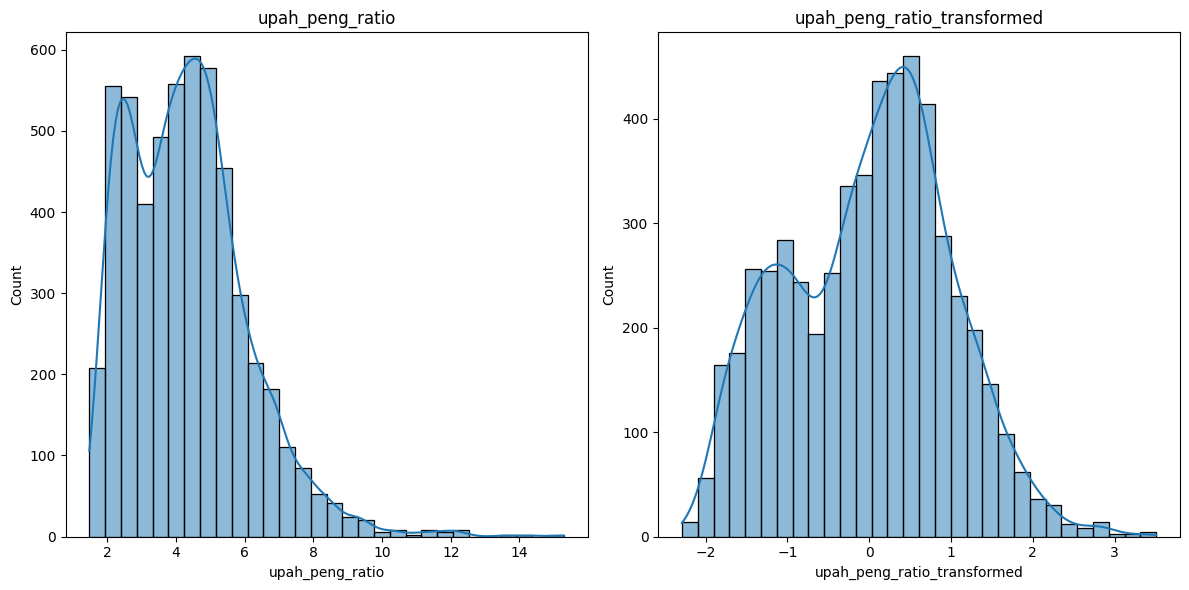

In [19]:
# Plot both `upah_peng_ratio` and `upah_peng_ratio_transformed`

%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(
    nrows = 1
    , ncols = 2
    , figsize = (12, 6)
)

sns.histplot(
    data = consol_df_encoded["upah_peng_ratio"]
    , bins = 30
    , kde = True
    , ax = axes[0]
)
axes[0].set_title("upah_peng_ratio")

sns.histplot(
    data = consol_df_encoded["upah_peng_ratio_transformed"]
    , bins = 30
    , kde = True
    , ax = axes[1]
)
axes[1].set_title("upah_peng_ratio_transformed")

plt.tight_layout()
plt.show()

Notice how the original `upah_peng_ratio` column has a right-skewed distribution, while the transformed `upah_peng_ratio_transformed` column appears more symmetric and bell-shaped.

Furthermore, the range of values in the original `upah_peng_ratio` column is much larger than the range of values in the transformed `upah_peng_ratio_transformed` column. This shortened range is similar to the (0,1) range of the multi-hot encoded columns.

Both the normalization, and the tightened range in `upah_peng_ratio_transformed` are beneficial for deep learning models that (usually) assume normality and require values within a similar range.

In [20]:
# Drop the original `upah_peng_ratio`
cols_to_drop: List[str] = ["upah_peng_ratio"]
existing_cols: List[str] = [each_col for each_col in cols_to_drop if each_col in consol_df_encoded.columns]

if existing_cols:
    # Drop the original `upah_peng_ratio` column
    consol_df_encoded = consol_df_encoded.drop(columns = existing_cols)

print("consol_df_encoded.info():")
consol_df_encoded.info()
print("##"*10)



consol_df_encoded.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5460 entries, 0 to 5459
Data columns (total 54 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   provinsi_ACEH                  5460 non-null   int64  
 1   provinsi_BALI                  5460 non-null   int64  
 2   provinsi_BANTEN                5460 non-null   int64  
 3   provinsi_BENGKULU              5460 non-null   int64  
 4   provinsi_DI YOGYAKARTA         5460 non-null   int64  
 5   provinsi_DKI JAKARTA           5460 non-null   int64  
 6   provinsi_GORONTALO             5460 non-null   int64  
 7   provinsi_INDONESIA             5460 non-null   int64  
 8   provinsi_JAMBI                 5460 non-null   int64  
 9   provinsi_JAWA BARAT            5460 non-null   int64  
 10  provinsi_JAWA TENGAH           5460 non-null   int64  
 11  provinsi_JAWA TIMUR            5460 non-null   int64  
 12  provinsi_KALIMANTAN BA

## Data Pre-Processing - Convert Pandas to Tensor and Split Dataset into Train : Validation : Test dataset

In this section, we will convert the processed Pandas DataFrame into Numpy Tensor format, and split the dataset into training, validation, and testing subsets for model training and evaluation.

Mathematically, we can imagine a Tensor as high-dimension metrics, where each dimensions represents a feature in the dataset. In our case, each dimension in Tensor represent the entries in multi-hot encoded columns, and one target numerical `upah_peng_ratio_transformed`.

Furthermore, we will conduct a brief 'experiment' whilst building a model.

Why do we need to experiment?

The need for experimenting, or trying several different configurations in deep learning is important, because many of the decision choices are usually dictated by the context and the problem at hand. That is, there is "Physics" rule that guide the choice.

Hence, in absence of these fundamental laws like those in hard-science, data scientists usually need to choose the best configuration from several candidates - and this is where experimentation comes in handy.

We will experiment with different model architectures, hyperparameters, and optimization techniques to find the best configuration for our model. This process is iterative and requires careful consideration of the trade-offs between model performance and computational resources.

In [21]:
import numpy as np

target_col: List[str] = ["upah_peng_ratio_transformed"]
existing_cols: List[str] = [each_col for each_col in consol_df_encoded.columns if each_col in target_col]

if existing_cols:
    # Splitting the consol_df_encoded into features and target
    # In our case, the features are the result from multi-hot one-encoded column
    # whilst the target would be the `upah_peng_ratio_transformed` column
    upr_ds: pd.Series = consol_df_encoded.pop("upah_peng_ratio_transformed")

print("upr_ds.info():")
consol_df_encoded.info()
print("##"*10)
print(f"upr_ds.shape: {upr_ds.shape}")
upr_ds.head(n=10)
print("##"*10)

# Here, we can directly convert the Pandas to Numpy, because we already deal with the `null` values and multi-hot encoding
# in the above section using Pandas
# We are creating Mathematical Tensor in Python using `np.ndarray`
feat_np: np.ndarray = consol_df_encoded.to_numpy()
tgt_np: np.ndarray = upr_ds.to_numpy()

# Inspecting the resulting Numpy array
print("feat_np info:")
print(f"shape: {feat_np.shape}")
print(f"dtype: {feat_np.dtype}")
print(f"ndim: {feat_np.ndim}")
print(f"size: {feat_np.size}")
print("##"*10)

print("tgt_np info:")
print(f"shape: {tgt_np.shape}")
print(f"dtype: {tgt_np.dtype}")
print(f"ndim: {tgt_np.ndim}")
print(f"size: {tgt_np.size}")
print("##"*10)

upr_ds.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5460 entries, 0 to 5459
Data columns (total 53 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   provinsi_ACEH                  5460 non-null   int64
 1   provinsi_BALI                  5460 non-null   int64
 2   provinsi_BANTEN                5460 non-null   int64
 3   provinsi_BENGKULU              5460 non-null   int64
 4   provinsi_DI YOGYAKARTA         5460 non-null   int64
 5   provinsi_DKI JAKARTA           5460 non-null   int64
 6   provinsi_GORONTALO             5460 non-null   int64
 7   provinsi_INDONESIA             5460 non-null   int64
 8   provinsi_JAMBI                 5460 non-null   int64
 9   provinsi_JAWA BARAT            5460 non-null   int64
 10  provinsi_JAWA TENGAH           5460 non-null   int64
 11  provinsi_JAWA TIMUR            5460 non-null   int64
 12  provinsi_KALIMANTAN BARAT      5460 non-null   int64
 13  pro

In this section, we will split the original Tensor dataset into smaller `train / val / test` Tensor dataset.

As noted, for this, we would make use of the `train_test_split` function from `sklearn.model_selection` module. This function allows us to split the dataset into training, validation, and testing sets with specified proportions and random state for reproducibility.

For our case, we would use a `train : val : test = 80 : 10 : 10` split. We achieve this by splitting the dataset in two-rounds: in the first round, we split the original dataset into `train : temp = 80 : 20` split; in the second round, we then split the temp dataset into `val : test = 50 : 50` split.

In [22]:
from sklearn.model_selection import train_test_split

# Creating First Split: train / temp
X_train, X_temp, y_train, y_temp = train_test_split(
    feat_np
    , tgt_np
    , test_size = 0.2
    , random_state = 42
)

# Creating Second Split: val / test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp
    , y_temp
    , test_size = 0.5
    , random_state = 42
)

## Remark: Building Multi-Layer Perceptron (MLP) Model
### Variation 01: Two-Hidden Layer MLP

Now, after splitting our dataset into `train : validation : test` groups, we proceed to build our MLP model.

We will create two variations: (1) one architecture is composed of two hidden-layers; and (2) another architecture is composed of four hidden layers. In that way, we can see how adding more layers (complexity) affects the model's final behavior.

In [23]:
# Building `model01` - a simpler architecture with only two-hidden layers
import tensorflow as tf

tf.keras.utils.set_random_seed(42)

model01: tf.keras.Sequential = tf.keras.Sequential([
    tf.keras.layers.Input(shape = (X_train.shape[1],), name = "input_layer")
    , tf.keras.layers.Dense(128, activation = "relu", name = "hidden_01")
    , tf.keras.layers.Dense(64, activation = "relu", name = "hidden_02")
    , tf.keras.layers.Dense(1, activation = "linear", name = "output_layer")
], name = "model01_two_hidden_layers")

model01.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-4)
    , loss = tf.keras.losses.MeanSquaredError()
    , metrics = [tf.keras.metrics.RootMeanSquaredError(name="rmse")]
)



2026-03-31 23:04:09.824889: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-31 23:04:09.824947: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-31 23:04:09.824962: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-31 23:04:10.021508: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-31 23:04:10.021554: I external/local_xla/xla/stream_executor

In [24]:
SEED: int = 42
EPOCHS: int = 100
BATCH_SIZE: int = 32

tf.keras.utils.set_random_seed(SEED)
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor = "val_loss"
    , patience = 10
    , restore_best_weights = True
)

# Training `model01`
model01_history: tf.keras.callbacks.History = model01.fit(
    X_train
    , y_train
    , validation_data = (X_val, y_val)
    , epochs = EPOCHS
    , batch_size = BATCH_SIZE
    , callbacks = [early_stopping]
    , verbose = 1
)



Epoch 1/100


I0000 00:00:1774973057.694732   28193 service.cc:145] XLA service 0x7f44fc01a7d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774973057.694776   28193 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Laptop GPU, Compute Capability 8.9
2026-03-31 23:04:17.716901: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-31 23:04:17.789566: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


 85/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9947 - rmse: 0.9971

I0000 00:00:1774973058.768928   28193 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.8627 - rmse: 0.9288 - val_loss: 0.6962 - val_rmse: 0.8344
Epoch 2/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5187 - rmse: 0.7202 - val_loss: 0.3775 - val_rmse: 0.6144
Epoch 3/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2591 - rmse: 0.5090 - val_loss: 0.2138 - val_rmse: 0.4624
Epoch 4/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1621 - rmse: 0.4026 - val_loss: 0.1563 - val_rmse: 0.3953
Epoch 5/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1220 - rmse: 0.3493 - val_loss: 0.1262 - val_rmse: 0.3553
Epoch 6/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1001 - rmse: 0.3163 - val_loss: 0.1093 - val_rmse: 0.3306
Epoch 7/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0874 - rmse: 0.2956 - val_loss: 0.0989 - val_rmse: 0.3144
Epoch 8/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0792 - rmse: 0.2814 - val_loss: 0.0915 - val_rmse: 0.3026
Epoch 9/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s

In [25]:
from matplotlib import pyplot as plt

# Create small utility function to plot Loss Evolution
def plot_loss(
        history: tf.keras.callbacks.History
        , title: str = "Loss Evolution"
        , x_label: str = "Epoch"
        , y_label: str = "Loss"
) -> None:
    fig, ax = plt.subplots(figsize = (14, 5))

    plt.plot(
        history.history["loss"]
        , label = "Training Loss"
    )

    if "val_loss" in history.history:
        plt.plot(
            history.history["val_loss"]
            , label = "Validation Loss"
            , linewidth = 2
        )

    ax.set_title(label = title)
    ax.set_xlabel(xlabel = x_label)
    ax.set_ylabel(ylabel = y_label)
    ax.legend()

    plt.tight_layout()
    plt.show()


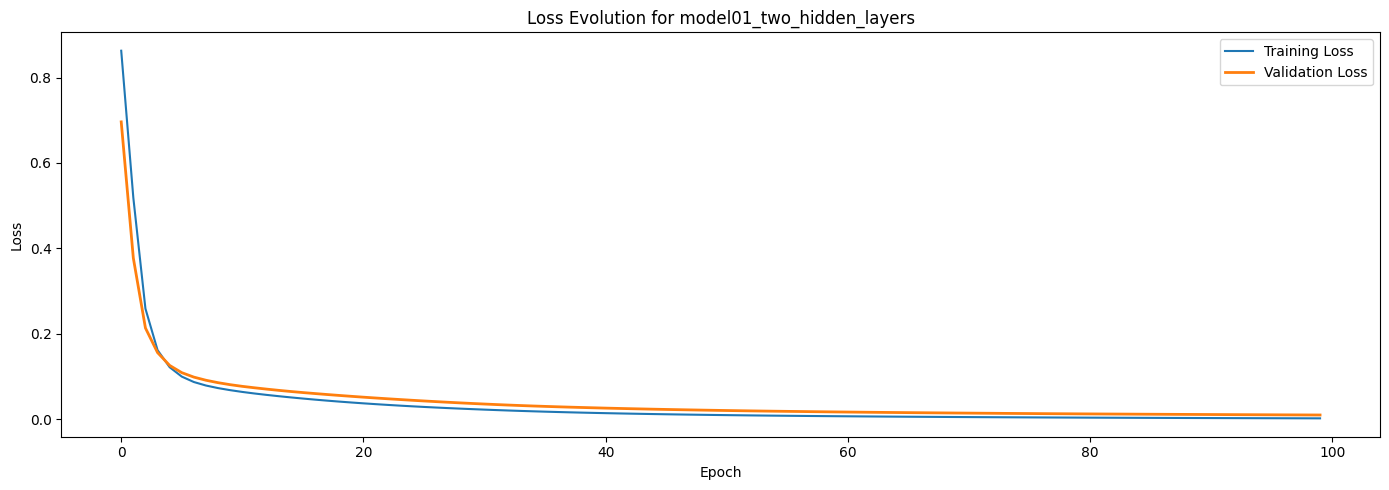

In [26]:
%matplotlib inline

plot_loss(
    history = model01_history
    , title = f"Loss Evolution for {model01.name}"
)

### Variation 02: Four-Hidden Layer MLP

In this alternative model `model02`, we will try with four hidden MLP layers.

Compared to `model01`, the `model02` has more nodes and more complexity. From what we have learnt so far, this so-called "more advanced" is expected to give better prediction compared to the simpler `model01` thanks to the more numerous count of nodes.

By comparing the two models, we will see if this hypothesis holds

In [27]:
model02: tf.keras.Sequential = tf.keras.Sequential([
    tf.keras.layers.Input(shape = (X_train.shape[1],), name = "input_layer")
    , tf.keras.layers.Dense(256, activation = "relu", name = "hidden_01")
    , tf.keras.layers.Dense(128, activation = "relu", name = "hidden_02")
    , tf.keras.layers.Dense(64, activation = "relu", name = "hidden_03")
    , tf.keras.layers.Dense(32, activation = "relu", name = "hidden_04")
    , tf.keras.layers.Dense(1, activation = "linear", name = "output_layer")
], name = "model02_four_hidden_layers")

model02.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-4)
    , loss = tf.keras.losses.MeanSquaredError()
    , metrics = [tf.keras.metrics.RootMeanSquaredError(name="rmse")]
)



In [28]:
SEED: int = 42
EPOCHS: int = 100
BATCH_SIZE: int = 32

tf.keras.utils.set_random_seed(SEED)
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor = "val_loss"
    , patience = 10
    , restore_best_weights = True
)

# Training `model02`
model02_history: tf.keras.callbacks.History = model02.fit(
    X_train
    , y_train
    , validation_data = (X_val, y_val)
    , epochs = EPOCHS
    , batch_size = BATCH_SIZE
    , callbacks = [early_stopping]
    , verbose = 1
)



Epoch 1/100


I0000 00:00:1774973111.676953   42286 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_433', 4 bytes spill stores, 4 bytes spill loads



137/137 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.5873 - rmse: 0.7664 - val_loss: 0.2580 - val_rmse: 0.5079
Epoch 2/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1655 - rmse: 0.4069 - val_loss: 0.1267 - val_rmse: 0.3559
Epoch 3/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0963 - rmse: 0.3103 - val_loss: 0.0913 - val_rmse: 0.3022
Epoch 4/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0739 - rmse: 0.2718 - val_loss: 0.0773 - val_rmse: 0.2781
Epoch 5/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0617 - rmse: 0.2485 - val_loss: 0.0684 - val_rmse: 0.2615
Epoch 6/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0526 - rmse: 0.2294 - val_loss: 0.0614 - val_rmse: 0.2478
Epoch 7/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0451 - rmse: 0.2123 - val_loss: 0.0556 - val_rmse: 0.2359
Epoch 8/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0386 - rmse: 0.1966 - val_loss: 0.0507 - val_rmse: 0.2251
Epoch 9/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s

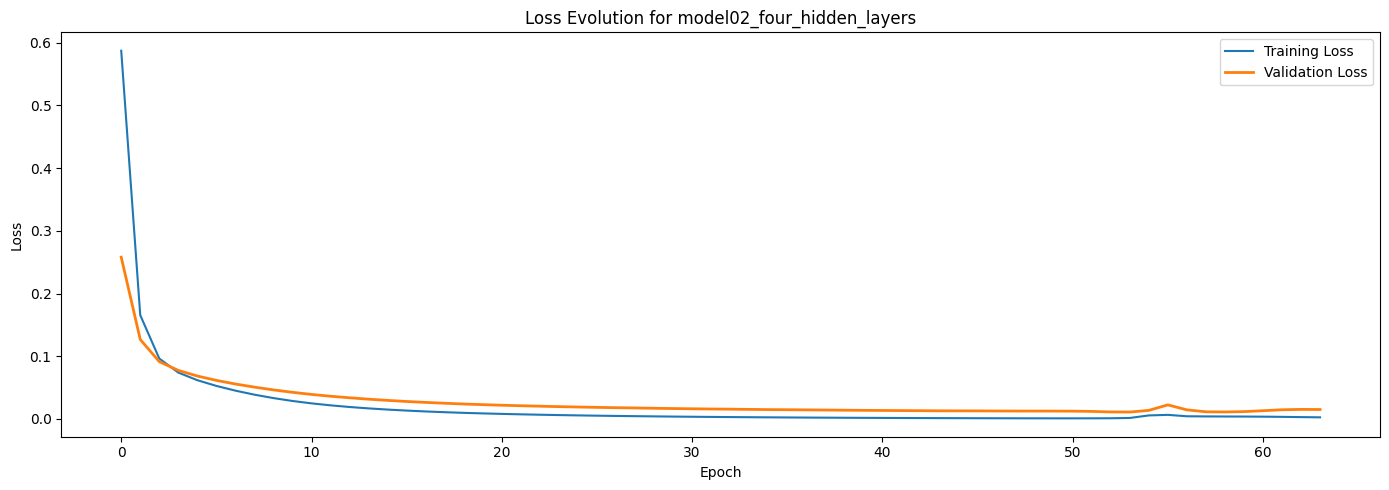

In [29]:
%matplotlib inline

plot_loss(
    history = model02_history
    , title = f"Loss Evolution for {model02.name}"
)

## 🧠Food for Thought

Question:

After training both `model01` (which has two-hidden layers) and `model02` (which has four-hidden layers), which model do you think will perform better on unseen data? Why?

Answer:
Although model02 has a deeper architecture and learns faster, model01 is expected to perform better on unseen data because it shows a more stable validation-loss curve and achieves a lower final validation loss. In contrast, model02 begins to fluctuate after around epoch 53, which suggests overfitting and weaker generalization. Therefore, model01 is the better choice for unseen data.

## Remark: Experimenting with Hyper Parameters

From comparing different layers, we can have better understanding about how model architecture affect the model's behavior in both training, as well as in production.

Now, we will switch our attention to one hyperparameter that we have encountered in session02, namely: the `learning_rate`.

We will use `model01` for this experiment, and varies solely the `learning_rate` hyper-parameter

In [30]:
import random

from matplotlib import pyplot as plt
import numpy as np
import tensorflow as tf

SEED: int = 42
EPOCHS: int = 100
BATCH_SIZE: int = 32

learning_rates: List[float] = sorted([
    1e-3
    , 1e-4
    , 1e-5
    , 1e-6
])

def reset_random_seed(
        my_seed: int = 42
) -> None:
    random.seed(my_seed)
    np.random.seed(my_seed)
    tf.random.set_seed(my_seed)


def build_model01(
        learning_rate: float = 1e-4
) -> tf.keras.Sequential:
    model01: tf.keras.Sequential = tf.keras.Sequential([
        tf.keras.layers.Input(shape = (X_train.shape[1],), name = "input_layer")
        , tf.keras.layers.Dense(128, activation = "relu", name = "hidden_01")
        , tf.keras.layers.Dense(64, activation = "relu", name = "hidden_02")
        , tf.keras.layers.Dense(1, activation = "linear", name = "output_layer")
    ], name = f"model01_lr_{learning_rate}")

    model01.compile(
        optimizer = tf.keras.optimizers.Adam(learning_rate = learning_rate)
        , loss = tf.keras.losses.MeanSquaredError()
        , metrics = [tf.keras.metrics.RootMeanSquaredError(name="rmse")]
    )

    return model01



In [31]:
from typing import Dict

histories: Dict = {}
trained_models: Dict = {}

for each_rate in learning_rates:

    print(f"Training model01 with learning_rate: {each_rate}")

    reset_random_seed(SEED)
    model01: tf.keras.Sequential = build_model01(learning_rate = each_rate)

    history: tf.keras.callbacks.History = model01.fit(
        X_train
        , y_train
        , validation_data = (X_val, y_val)
        , epochs = EPOCHS
        , batch_size = BATCH_SIZE
        , callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor = "val_loss"
                , patience = 10
                , restore_best_weights = True
            )
        ]
        , verbose = 0
    )

    histories[str(each_rate)] = history
    trained_models[str(each_rate)] = model01



Training model01 with learning_rate: 1e-06
Training model01 with learning_rate: 1e-05
Training model01 with learning_rate: 0.0001
Training model01 with learning_rate: 0.001


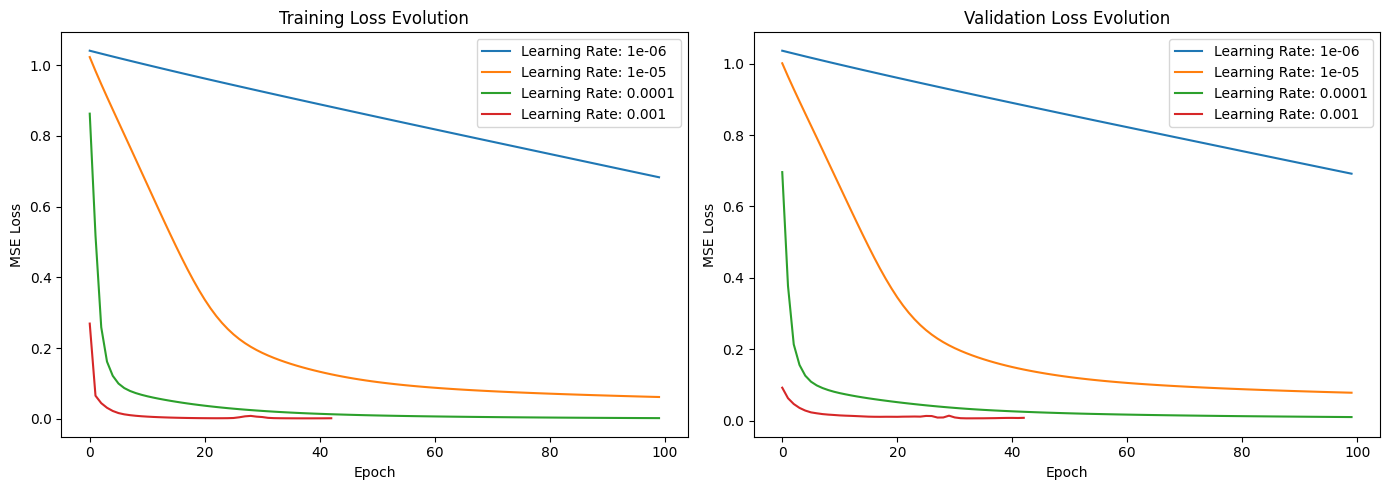

In [32]:
%matplotlib inline

fig, axs = plt.subplots(
    nrows = 1
    , ncols = 2
    , figsize = (14, 5)
)

for each_lr, each_history in histories.items():

    axs[0].plot(
        each_history.history["loss"]
        , label = f"Learning Rate: {each_lr}"
    )

    axs[1].plot(
        each_history.history["val_loss"]
        , label = f"Learning Rate: {each_lr}"
    )


axs[0].set_title("Training Loss Evolution")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("MSE Loss")
axs[0].legend()

axs[1].set_title("Validation Loss Evolution")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("MSE Loss")
axs[1].legend()

plt.tight_layout()
plt.show()

## 🧠 Food for Thought

Question:

So, what do you think about the impact of learning rate on model training performance? How does this connects to what he have learnt thus far?

Answer :

The learning rate has a strong impact on training performance because it controls the step size of weight updates during backpropagation. A very small learning rate such as 1e-6 makes the model learn very slowly, while a larger learning rate such as 1e-3 allows faster learning but may introduce instability or fluctuations. From the results, 1e-4 appears to provide the best balance, since both training and validation loss decrease quickly and remain stable.

This is closely related to what we have learned about gradient descent and backpropagation. During training, the model updates its weights based on the error gradient, and the learning rate determines how large each update will be. Therefore, choosing an appropriate learning rate is essential to achieve efficient convergence and good generalization on unseen data.